In [1]:
import os
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_scheduler

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Mount Google Drive and set working directory
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/roman_urdu_sentiment')

print("All libraries imported successfully")
print("GPU available:", torch.cuda.is_available())

All libraries imported successfully
GPU available: True


In [2]:
df = pd.read_csv('rusad_cleaned.csv')

print(df.shape)
print(df['label_encoded'].value_counts())

(10999, 2)
label_encoded
1    5699
0    5300
Name: count, dtype: int64


In [3]:
X = df['cleaned_text'].values
y = df['label_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8799
Testing samples: 2200


In [4]:
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')

print("Tokenizer loaded successfully")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully


In [5]:
class RomanUrduDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = RomanUrduDataset(X_train, y_train, tokenizer)
test_dataset = RomanUrduDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 550
Testing batches: 138


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = AutoModelForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=2)
model = model.to(device)

print("Model loaded on:", device)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cuda


In [7]:
optimizer = AdamW(model.parameters(), lr=2e-5)

num_epochs = 3
num_training_steps = num_epochs * len(train_loader)

lr_scheduler = get_scheduler(
    'linear',
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

print("Training steps:", num_training_steps)

Training steps: 1650


In [8]:
from tqdm import tqdm

model.train()

for epoch in range(num_epochs):
    total_loss = 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch + 1} - Average Loss: {avg_loss:.4f}')

Epoch 1: 100%|██████████| 550/550 [02:05<00:00,  4.38it/s]


Epoch 1 - Average Loss: 0.6410


Epoch 2: 100%|██████████| 550/550 [01:57<00:00,  4.69it/s]


Epoch 2 - Average Loss: 0.4767


Epoch 3: 100%|██████████| 550/550 [01:57<00:00,  4.69it/s]

Epoch 3 - Average Loss: 0.3832


In [9]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluating'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

Evaluating: 100%|██████████| 138/138 [00:08<00:00, 17.19it/s]

              precision    recall  f1-score   support

    Negative       0.80      0.80      0.80      1060
    Positive       0.81      0.81      0.81      1140

    accuracy                           0.81      2200
   macro avg       0.81      0.81      0.81      2200
weighted avg       0.81      0.81      0.81      2200



In [11]:
model = AutoModelForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=2)
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=1e-5)

num_epochs = 5
num_training_steps = num_epochs * len(train_loader)

lr_scheduler = get_scheduler(
    'linear',
    optimizer=optimizer,
    num_warmup_steps=50,
    num_training_steps=num_training_steps
)

model.train()

for epoch in range(num_epochs):
    total_loss = 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch + 1} - Average Loss: {avg_loss:.4f}')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1: 100%|██████████| 550/550 [01:56<00:00,  4.70it/s]


Epoch 1 - Average Loss: 0.5854


Epoch 2: 100%|██████████| 550/550 [01:57<00:00,  4.69it/s]


Epoch 2 - Average Loss: 0.4317


...

Epoch 3 - Average Loss: 0.3653


Epoch 4: 100%|██████████| 550/550 [01:57<00:00,  4.69it/s]


Epoch 4 - Average Loss: 0.3089


Epoch 5: 100%|██████████| 550/550 [01:57<00:00,  4.69it/s]

Epoch 5 - Average Loss: 0.2766


In [12]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluating'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

Evaluating: 100%|██████████| 138/138 [00:07<00:00, 17.60it/s]

              precision    recall  f1-score   support

    Negative       0.82      0.81      0.82      1060
    Positive       0.82      0.84      0.83      1140

    accuracy                           0.82      2200
   macro avg       0.82      0.82      0.82      2200
weighted avg       0.82      0.82      0.82      2200



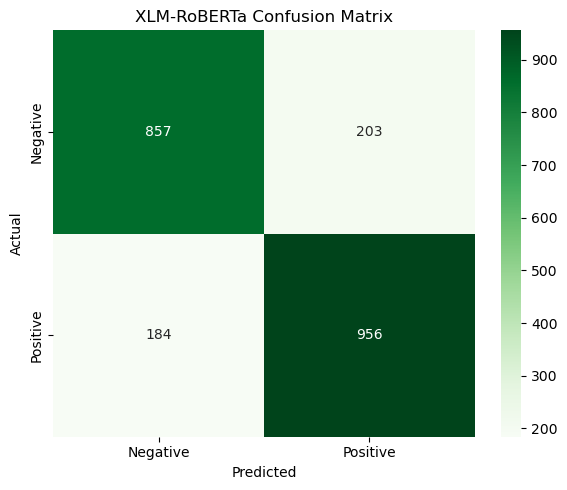

In [13]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('XLM-RoBERTa Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('XLMRoBERTa_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
model.save_pretrained('xlmroberta_finetuned')
tokenizer.save_pretrained('xlmroberta_finetuned')

print("Model saved successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully


In [ ]:
# Zip the fine-tuned model folder and download it from Colab
import zipfile, os
from google.colab import files

zip_path = 'xlmroberta_finetuned.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, filenames in os.walk('xlmroberta_finetuned'):
        for filename in filenames:
            filepath = os.path.join(root, filename)
            zf.write(filepath)

print(f'Zipped to {zip_path}')
files.download(zip_path)


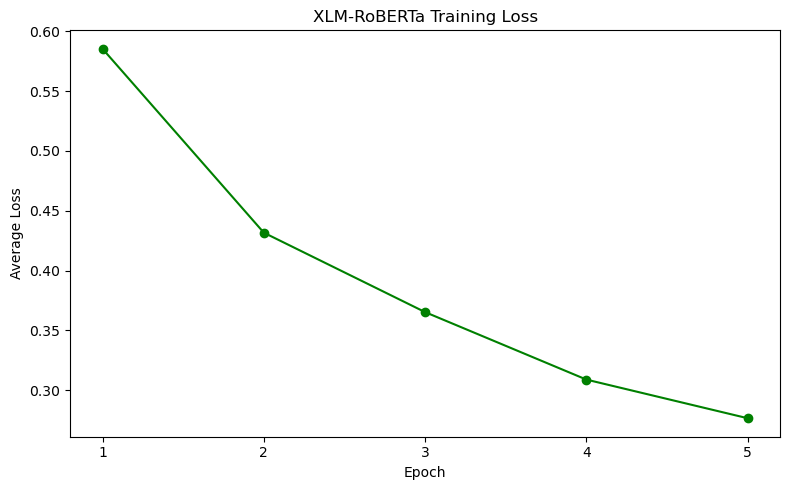

In [15]:
plt.figure(figsize=(8, 5))
plt.plot([1, 2, 3, 4, 5], [0.5854, 0.4317, 0.3653, 0.3089, 0.2766], marker='o', color='green')
plt.title('XLM-RoBERTa Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig('XLMRoBERTa_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()